# Synthetic Data Validation for 3-Compartment DEXSY

This notebook reproduces the Section 3.1 validation logic for 3-compartment (3C) systems.

Validation follows the same two-layer approach as 2C:
- **Generator consistency**: compare the exact DEI implied by the compartment-level weight matrix against the rasterised spectrum.
- **ILT stability**: compare the ILT-reconstructed DEI against the same exact generator-side reference.

For 3C systems, we also include pairwise DEI analysis to understand the exchange structure.

In [1]:
from pathlib import Path

import sys

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start=None):
    start_path = Path.cwd() if start is None else Path(start)
    candidates = [start_path] + list(start_path.resolve().parents)
    for candidate in candidates:
        if (candidate / 'dexsy_core').exists() and (candidate / 'notebooks' / 'validation_3c_synthetic_data.ipynb').exists():
            return candidate
    for candidate in candidates:
        if (candidate / 'dexsy_core').exists():
            return candidate
    raise FileNotFoundError('Could not find the repo root.')


ROOT = find_repo_root()
if str(ROOT / 'dexsy_core') not in sys.path:
    sys.path.insert(0, str(ROOT / 'dexsy_core'))

from forward_model import ForwardModel2D, compute_dei, compute_pairwise_3c_dei

In [2]:
fm = ForwardModel2D(n_d=64, n_b=64)

print('Forward Model Parameters:')
print(f'  D range: {fm.D1[0]:.2e} to {fm.D1[-1]:.2e} m^2/s')
print('  Compartment ranges:')
for name, (dmin, dmax) in fm.compartment_ranges.items():
    print(f'    {name}: {dmin:.2e} to {dmax:.2e} m^2/s')
print(f'  b range: {fm.b1[0]:.2e} to {fm.b1[-1]:.2e} s/m^2')
print(f'  mixing time range: {fm.mixing_time_range[0]:.3f} - {fm.mixing_time_range[1]:.3f} s')
print(f'  exchange rate range: {fm.exchange_rate_range[0]:.1f} - {fm.exchange_rate_range[1]:.1f} s^-1')
print(f'  spectral broadening mode: {fm.spectral_broadening_mode}')
print(f'  default smoothing sigma range: {fm.smoothing_sigma_range}')

Forward Model Parameters:
  D range: 5.00e-12 to 5.00e-08 m^2/s
  Compartment ranges:
    intracellular: 5.00e-12 to 3.00e-11 m^2/s
    extracellular: 3.00e-11 to 5.00e-09 m^2/s
    fast: 5.00e-09 to 5.00e-08 m^2/s
  b range: 0.00e+00 to 1.30e+10 s/m^2
  mixing time range: 0.015 - 0.300 s
  exchange rate range: 0.1 - 30.0 s^-1
  spectral broadening mode: directional
  default smoothing sigma range: (0.65, 1.15)


## 3C Spectrum Example

First, let's generate a 3C sample to visualize the 9-peak structure.

3C Sample Parameters:
  Diffusions: ['9.29e-12', '2.20e-09', '2.13e-08']
  Volume fractions: ['0.611', '0.130', '0.259']
  Exchange rates: {'0-1': 3.2196816888482522, '0-2': 5.28706665772317, '1-2': 1.5300660021681267}
  Mixing time: 0.135 s
  Theoretical DEI: 0.2997
  Global DEI (from spectrum): 0.2997


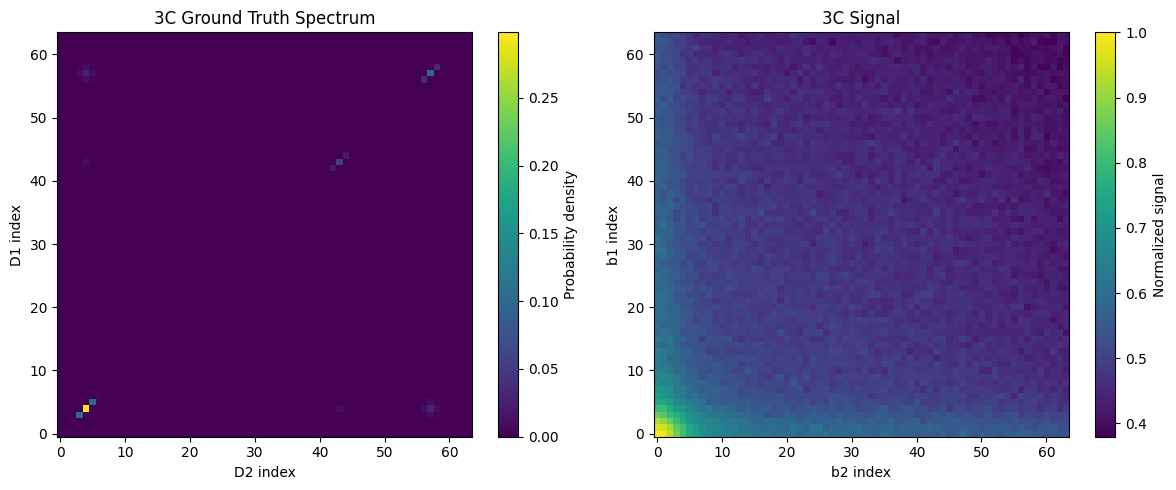

In [3]:
# Generate a 3C sample
f, s, params = fm.generate_sample(n_compartments=3)

print(f'3C Sample Parameters:')
print(f'  Diffusions: {[f"{d:.2e}" for d in params["diffusions"]]}')
print(f'  Volume fractions: {[f"{v:.3f}" for v in params["volume_fractions"]]}')
print(f'  Exchange rates: {params["exchange_rates"]}')
print(f'  Mixing time: {params["mixing_time"]:.3f} s')
print(f'  Theoretical DEI: {params["theoretical_dei"]:.4f}')
print(f'  Global DEI (from spectrum): {compute_dei(f):.4f}')

# Plot spectrum
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(f, origin='lower', aspect='auto', cmap='viridis')
axes[0].set_title('3C Ground Truth Spectrum')
axes[0].set_xlabel('D2 index')
axes[0].set_ylabel('D1 index')
plt.colorbar(im0, ax=axes[0], label='Probability density')

im1 = axes[1].imshow(s, origin='lower', aspect='auto', cmap='viridis')
axes[1].set_title('3C Signal')
axes[1].set_xlabel('b2 index')
axes[1].set_ylabel('b1 index')
plt.colorbar(im1, ax=axes[1], label='Normalized signal')

plt.tight_layout()
plt.show()

## 实验 I-3C: 固定峰位置，变化交换强度

固定三个峰在 intracellular, extracellular, fast 区域的位置，只改变 exchange rates。

记录：
- Exact ground-truth DEI（直接来自 weight matrix）
- Rasterised ground-truth DEI（从平滑后 spectrum 的局部 peak blobs 计算）
- ILT reconstructed DEI
- Pairwise DEI breakdown

In [4]:
ILT_KW = dict(alpha=0.02, post_sharpen=True, sharpen_sigma=0.9, sharpen_strength=0.30)
VALIDATION_SMOOTHING_SIGMA = 0.6
VALIDATION_BLOB_RADIUS = 4

OUTPUT_DIR = ROOT / 'validation_output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def identity_ci_band(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    """Return mean residual and 95% residual half-width for an identity-line band."""
    residual = y - x
    if residual.size <= 1:
        return float(residual.mean()) if residual.size else 0.0, 0.0
    center = float(np.mean(residual))
    half_width = float(1.96 * np.std(residual, ddof=1))
    return center, half_width


def residual_95_half_width(reference: np.ndarray, estimate: np.ndarray) -> float:
    """Return a 95% residual half-width around the exact reference."""
    residual = estimate - reference
    if residual.size <= 1:
        return 0.0
    return float(1.96 * np.std(residual, ddof=1))

In [5]:
def run_experiment_i_3c(fm: ForwardModel2D, n_samples: int = 10, random_seed: int = 42) -> dict:
    """
    Experiment I for 3C: vary exchange rates with fixed compartment diffusivities.
    
    We test 4 cases:
    - Case A: rate_01 varies, others fixed
    - Case B: rate_02 varies, others fixed
    - Case C: rate_12 varies, others fixed
    - Case D: all rates vary together
    """
    np.random.seed(random_seed)

    # Fixed parameters
    d_intra = 8e-12
    d_extra = 3e-9
    d_fast = 1e-8
    vf = np.array([0.33, 0.34, 0.33], dtype=np.float64)
    mixing_time = 0.1
    
    # Exchange rate ranges
    rate_min, rate_max = 0.5, 25.0
    fixed_rate = 5.0
    exchange_rates_array = np.linspace(rate_min, rate_max, n_samples)

    results = {}
    
    # Case A: rate_01 varies
    print('Case A: rate_01 varies, rate_02=rate_12=fixed')
    exact_dei_a, raster_dei_a, ilt_dei_a = [], [], []
    for rate in exchange_rates_array:
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([d_intra, d_extra, d_fast]),
            vf,
            (rate, fixed_rate, fixed_rate),
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei_a.append(params['theoretical_dei'])
        raster_dei_a.append(compute_dei(spectrum_gt))
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei_a.append(compute_dei(spectrum_ilt))
    results['case_a'] = {
        'exchange_rates': exchange_rates_array,
        'exact': np.array(exact_dei_a),
        'raster': np.array(raster_dei_a),
        'ilt': np.array(ilt_dei_a),
        'varying_param': 'rate_01',
    }
    print(f'  Completed {n_samples} samples')
    
    # Case B: rate_02 varies
    print('Case B: rate_02 varies, rate_01=rate_12=fixed')
    exact_dei_b, raster_dei_b, ilt_dei_b = [], [], []
    for rate in exchange_rates_array:
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([d_intra, d_extra, d_fast]),
            vf,
            (fixed_rate, rate, fixed_rate),
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei_b.append(params['theoretical_dei'])
        raster_dei_b.append(compute_dei(spectrum_gt))
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei_b.append(compute_dei(spectrum_ilt))
    results['case_b'] = {
        'exchange_rates': exchange_rates_array,
        'exact': np.array(exact_dei_b),
        'raster': np.array(raster_dei_b),
        'ilt': np.array(ilt_dei_b),
        'varying_param': 'rate_02',
    }
    print(f'  Completed {n_samples} samples')
    
    # Case C: rate_12 varies
    print('Case C: rate_12 varies, rate_01=rate_02=fixed')
    exact_dei_c, raster_dei_c, ilt_dei_c = [], [], []
    for rate in exchange_rates_array:
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([d_intra, d_extra, d_fast]),
            vf,
            (fixed_rate, fixed_rate, rate),
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei_c.append(params['theoretical_dei'])
        raster_dei_c.append(compute_dei(spectrum_gt))
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei_c.append(compute_dei(spectrum_ilt))
    results['case_c'] = {
        'exchange_rates': exchange_rates_array,
        'exact': np.array(exact_dei_c),
        'raster': np.array(raster_dei_c),
        'ilt': np.array(ilt_dei_c),
        'varying_param': 'rate_12',
    }
    print(f'  Completed {n_samples} samples')
    
    # Case D: all rates vary together
    print('Case D: all rates vary together')
    exact_dei_d, raster_dei_d, ilt_dei_d = [], [], []
    for rate in exchange_rates_array:
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([d_intra, d_extra, d_fast]),
            vf,
            (rate, rate, rate),
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei_d.append(params['theoretical_dei'])
        raster_dei_d.append(compute_dei(spectrum_gt))
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei_d.append(compute_dei(spectrum_ilt))
    results['case_d'] = {
        'exchange_rates': exchange_rates_array,
        'exact': np.array(exact_dei_d),
        'raster': np.array(raster_dei_d),
        'ilt': np.array(ilt_dei_d),
        'varying_param': 'all_rates',
    }
    print(f'  Completed {n_samples} samples')
    
    return results

In [6]:
results_i = run_experiment_i_3c(fm, n_samples=10, random_seed=42)

Case A: rate_01 varies, rate_02=rate_12=fixed
  Completed 10 samples
Case B: rate_02 varies, rate_01=rate_12=fixed
  Completed 10 samples
Case C: rate_12 varies, rate_01=rate_02=fixed
  Completed 10 samples
Case D: all rates vary together
  Completed 10 samples


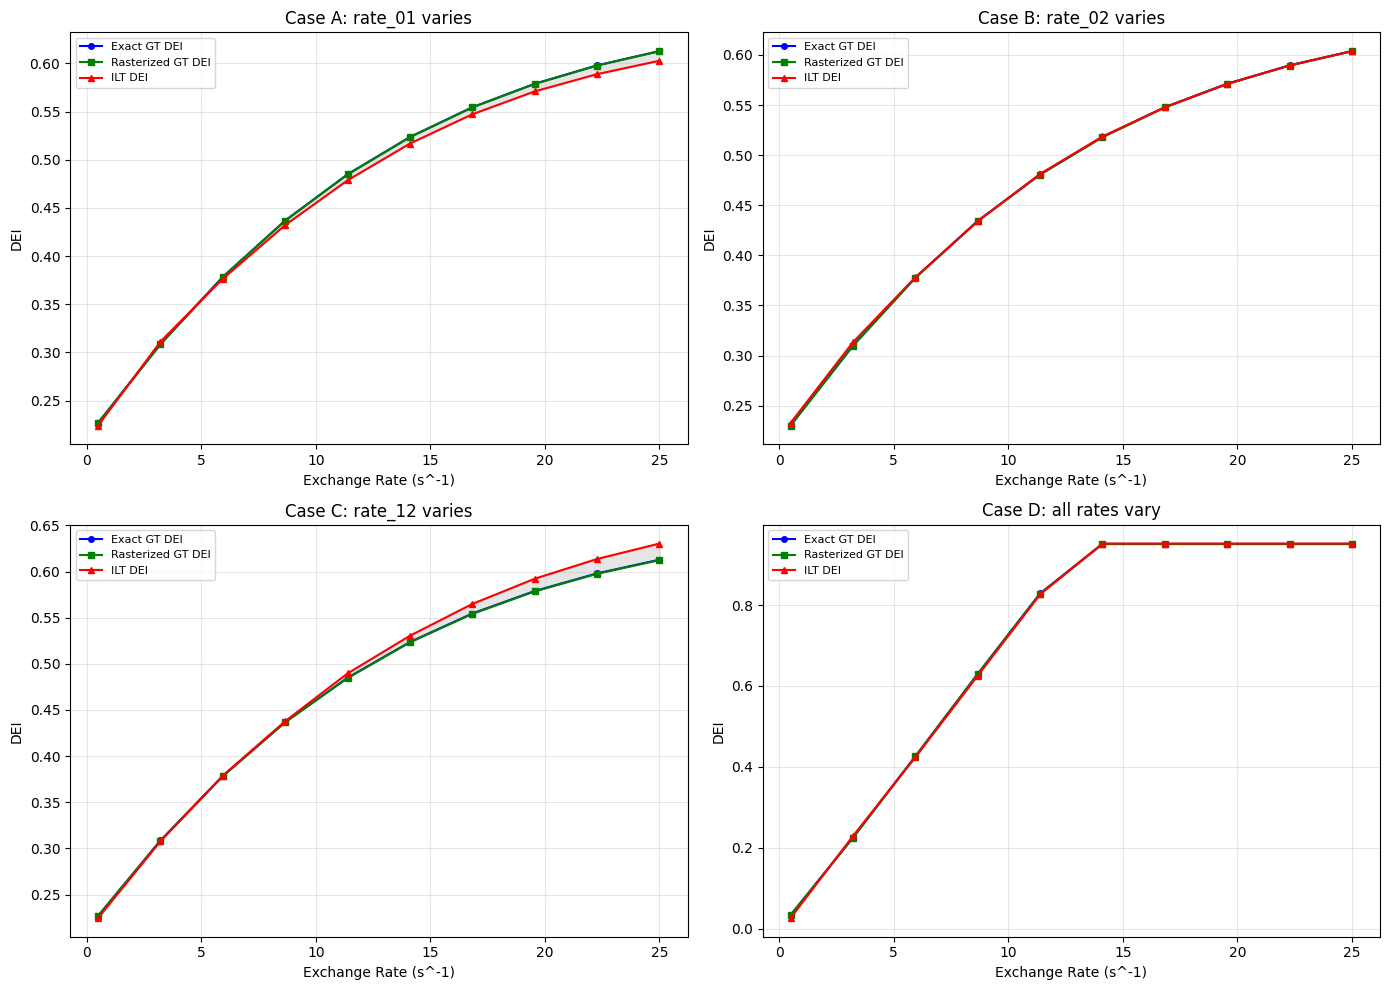

In [7]:
# Plot Experiment I results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

case_names = ['Case A: rate_01 varies', 'Case B: rate_02 varies', 
               'Case C: rate_12 varies', 'Case D: all rates vary']

for idx, (case_key, case_name) in enumerate(zip(['case_a', 'case_b', 'case_c', 'case_d'], case_names)):
    r = results_i[case_key]
    ax = axes[idx]
    
    ax.plot(r['exchange_rates'], r['exact'], 'b-o', label='Exact GT DEI', markersize=4)
    ax.plot(r['exchange_rates'], r['raster'], 'g-s', label='Rasterized GT DEI', markersize=4)
    ax.plot(r['exchange_rates'], r['ilt'], 'r-^', label='ILT DEI', markersize=4)
    
    # Add shaded region between raster and ILT to show reconstruction quality
    ax.fill_between(r['exchange_rates'], r['raster'], r['ilt'], alpha=0.2, color='gray')
    
    ax.set_xlabel('Exchange Rate (s^-1)')
    ax.set_ylabel('DEI')
    ax.set_title(case_name)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'experiment_i_3c_dei_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Print summary statistics
print('Experiment I-3C Summary:')
for case_key, case_name in zip(['case_a', 'case_b', 'case_c', 'case_d'], case_names):
    r = results_i[case_key]
    bias, ci = identity_ci_band(r['exact'], r['ilt'])
    raster_bias, raster_ci = identity_ci_band(r['exact'], r['raster'])
    print(f'  {case_name}:')
    print(f'    Exact vs ILT bias: {bias:.4f}, 95% CI width: {ci:.4f}')
    print(f'    Rasterized vs Exact bias: {raster_bias:.4f}, 95% CI width: {raster_ci:.4f}')

Experiment I-3C Summary:
  Case A: rate_01 varies:
    Exact vs ILT bias: -0.0054, 95% CI width: 0.0075
    Rasterized vs Exact bias: -0.0002, 95% CI width: 0.0001
  Case B: rate_02 varies:
    Exact vs ILT bias: 0.0007, 95% CI width: 0.0025
    Rasterized vs Exact bias: -0.0002, 95% CI width: 0.0001
  Case C: rate_12 varies:
    Exact vs ILT bias: 0.0066, 95% CI width: 0.0141
    Rasterized vs Exact bias: -0.0003, 95% CI width: 0.0003
  Case D: all rates vary:
    Exact vs ILT bias: -0.0008, 95% CI width: 0.0064
    Rasterized vs Exact bias: -0.0004, 95% CI width: 0.0004


In [9]:
def get_diffusion_at_alpha(fm, compartment_range_name: str, alpha: float) -> float:
    """
    Get a diffusion value from a compartment range at a given alpha position.
    
    alpha=0 -> near minimum of range
    alpha=1 -> near maximum of range
    """
    dmin, dmax = fm.compartment_ranges[compartment_range_name]
    log_dmin, log_dmax = np.log(dmin), np.log(dmax)
    # Use log space for uniform sampling
    log_d = log_dmin + alpha * (log_dmax - log_dmin)
    return float(np.exp(log_d))


def run_experiment_ii_3c(fm: ForwardModel2D, n_samples: int = 10, random_seed: int = 42) -> dict:
    """
    Experiment II for 3C: vary peak positions with fixed exchange rates.
    
    We test 3 cases:
    - Moving intracellular peak
    - Moving extracellular peak
    - Moving fast peak
    """
    np.random.seed(random_seed)

    # Fixed parameters
    vf = np.array([0.33, 0.34, 0.33], dtype=np.float64)
    mixing_time = 0.1
    rate_01, rate_02, rate_12 = 5.0, 5.0, 5.0
    alphas = np.linspace(0.1, 0.9, n_samples)  # Avoid edge cases

    results = {}
    
    # Case A: Move intracellular peak
    print('Case A: Moving intracellular peak, extra and fast fixed')
    d_extra_fixed = get_diffusion_at_alpha(fm, 'extracellular', 0.5)
    d_fast_fixed = get_diffusion_at_alpha(fm, 'fast', 0.5)
    
    exact_dei_a, raster_dei_a, ilt_dei_a = [], [], []
    for alpha in alphas:
        d_intra = get_diffusion_at_alpha(fm, 'intracellular', alpha)
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([d_intra, d_extra_fixed, d_fast_fixed]),
            vf,
            (rate_01, rate_02, rate_12),
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei_a.append(params['theoretical_dei'])
        raster_dei_a.append(compute_dei(spectrum_gt))
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei_a.append(compute_dei(spectrum_ilt))
    results['case_a'] = {
        'alphas': alphas,
        'diffusion_values': [get_diffusion_at_alpha(fm, 'intracellular', a) for a in alphas],
        'exact': np.array(exact_dei_a),
        'raster': np.array(raster_dei_a),
        'ilt': np.array(ilt_dei_a),
        'moving_compartment': 'intracellular',
    }
    print(f'  Completed {n_samples} samples')
    
    # Case B: Move extracellular peak
    print('Case B: Moving extracellular peak, intra and fast fixed')
    d_intra_fixed = get_diffusion_at_alpha(fm, 'intracellular', 0.5)
    d_fast_fixed = get_diffusion_at_alpha(fm, 'fast', 0.5)
    
    exact_dei_b, raster_dei_b, ilt_dei_b = [], [], []
    for alpha in alphas:
        d_extra = get_diffusion_at_alpha(fm, 'extracellular', alpha)
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([d_intra_fixed, d_extra, d_fast_fixed]),
            vf,
            (rate_01, rate_02, rate_12),
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei_b.append(params['theoretical_dei'])
        raster_dei_b.append(compute_dei(spectrum_gt))
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei_b.append(compute_dei(spectrum_ilt))
    results['case_b'] = {
        'alphas': alphas,
        'diffusion_values': [get_diffusion_at_alpha(fm, 'extracellular', a) for a in alphas],
        'exact': np.array(exact_dei_b),
        'raster': np.array(raster_dei_b),
        'ilt': np.array(ilt_dei_b),
        'moving_compartment': 'extracellular',
    }
    print(f'  Completed {n_samples} samples')
    
    # Case C: Move fast peak
    print('Case C: Moving fast peak, intra and extra fixed')
    d_intra_fixed = get_diffusion_at_alpha(fm, 'intracellular', 0.5)
    d_extra_fixed = get_diffusion_at_alpha(fm, 'extracellular', 0.5)
    
    exact_dei_c, raster_dei_c, ilt_dei_c = [], [], []
    for alpha in alphas:
        d_fast = get_diffusion_at_alpha(fm, 'fast', alpha)
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([d_intra_fixed, d_extra_fixed, d_fast]),
            vf,
            (rate_01, rate_02, rate_12),
            mixing_time,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        exact_dei_c.append(params['theoretical_dei'])
        raster_dei_c.append(compute_dei(spectrum_gt))
        spectrum_ilt = fm.compute_ilt_nnls(clean_signal, **ILT_KW)
        ilt_dei_c.append(compute_dei(spectrum_ilt))
    results['case_c'] = {
        'alphas': alphas,
        'diffusion_values': [get_diffusion_at_alpha(fm, 'fast', a) for a in alphas],
        'exact': np.array(exact_dei_c),
        'raster': np.array(raster_dei_c),
        'ilt': np.array(ilt_dei_c),
        'moving_compartment': 'fast',
    }
    print(f'  Completed {n_samples} samples')
    
    return results

In [10]:
results_ii = run_experiment_ii_3c(fm, n_samples=10, random_seed=42)

Case A: Moving intracellular peak, extra and fast fixed
  Completed 10 samples
Case B: Moving extracellular peak, intra and fast fixed
  Completed 10 samples
Case C: Moving fast peak, intra and extra fixed
  Completed 10 samples


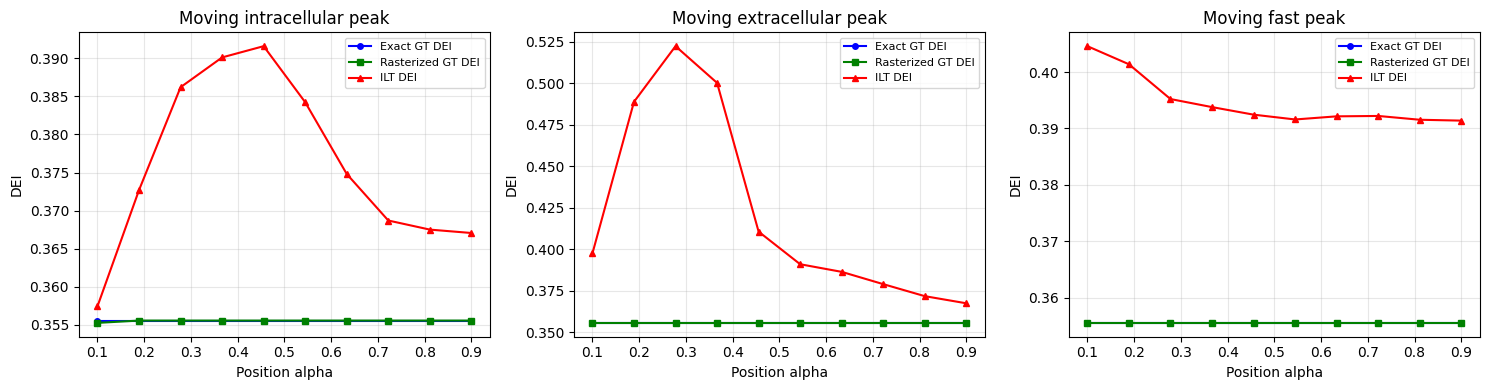

In [11]:
# Plot Experiment II results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

case_names_ii = [
    'Moving intracellular peak',
    'Moving extracellular peak',
    'Moving fast peak'
]

for idx, (case_key, case_name) in enumerate(zip(['case_a', 'case_b', 'case_c'], case_names_ii)):
    r = results_ii[case_key]
    ax = axes[idx]
    
    # Plot vs alpha
    ax.plot(r['alphas'], r['exact'], 'b-o', label='Exact GT DEI', markersize=4)
    ax.plot(r['alphas'], r['raster'], 'g-s', label='Rasterized GT DEI', markersize=4)
    ax.plot(r['alphas'], r['ilt'], 'r-^', label='ILT DEI', markersize=4)
    
    ax.set_xlabel('Position alpha')
    ax.set_ylabel('DEI')
    ax.set_title(case_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'experiment_ii_3c_dei_vs_position.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Print summary statistics for Experiment II
print('Experiment II-3C Summary (DEI stability under position changes):')
for case_key, case_name in zip(['case_a', 'case_b', 'case_c'], case_names_ii):
    r = results_ii[case_key]
    print(f'  {case_name}:')
    print(f'    Exact DEI std: {np.std(r["exact"]):.4f} (should be ~0)')
    print(f'    ILT DEI std: {np.std(r["ilt"]):.4f}')
print('  ')
print('  Interpretation: Exact DEI is stable (as expected), ILT shows position-dependent bias.')

Experiment II-3C Summary (DEI stability under position changes):
  Moving intracellular peak:
    Exact DEI std: 0.0000 (should be ~0)
    ILT DEI std: 0.0109
  Moving extracellular peak:
    Exact DEI std: 0.0000 (should be ~0)
    ILT DEI std: 0.0556
  Moving fast peak:
    Exact DEI std: 0.0000 (should be ~0)
    ILT DEI std: 0.0044
  
  Interpretation: Exact DEI is stable (as expected), ILT shows position-dependent bias.


## Pairwise DEI Analysis

For 3C systems, we can analyze the exchange contribution from each pair of compartments separately.
This helps understand which exchanges dominate the overall DEI.

In [13]:
def analyze_pairwise_dei(fm: ForwardModel2D, n_samples: int = 5, random_seed: int = 42) -> dict:
    """
    Analyze pairwise DEI contributions in 3C systems.
    """
    np.random.seed(random_seed)
    
    results = {
        'pairwise_dei_01': [],
        'pairwise_dei_02': [],
        'pairwise_dei_12': [],
        'global_dei': [],
        'weight_matrix_dei': [],
    }
    
    print('Pairwise DEI Analysis:')
    for i in range(n_samples):
        spectrum_gt, clean_signal, params = fm.generate_3c_validation_spectrum(
            np.array([8e-12, 3e-9, 1e-8]),
            np.array([0.33, 0.34, 0.33]),
            (5.0, 5.0, 5.0),
            0.1,
            jitter_pixels=0,
            smoothing_sigma=VALIDATION_SMOOTHING_SIGMA,
        )
        
        compartment_indices = params['compartment_indices']
        pairwise = compute_pairwise_3c_dei(spectrum_gt, compartment_indices)
        
        results['pairwise_dei_01'].append(pairwise['dei_01_blob'])
        results['pairwise_dei_02'].append(pairwise['dei_02_blob'])
        results['pairwise_dei_12'].append(pairwise['dei_12_blob'])
        results['global_dei'].append(compute_dei(spectrum_gt))
        results['weight_matrix_dei'].append(params['theoretical_dei'])
        
        print(f'  Sample {i+1}: WM_DEI={params["theoretical_dei"]:.4f}, '
              f'Global={compute_dei(spectrum_gt):.4f}, '
              f'Pair01={pairwise["dei_01_blob"]:.4f}, '
              f'Pair02={pairwise["dei_02_blob"]:.4f}, '
              f'Pair12={pairwise["dei_12_blob"]:.4f}')
    
    return {k: np.array(v) for k, v in results.items()}

In [14]:
pairwise_results = analyze_pairwise_dei(fm, n_samples=5)

Pairwise DEI Analysis:
  Sample 1: WM_DEI=0.3555, Global=0.3554, Pair01=0.1785, Pair02=0.1763, Pair12=0.1785
  Sample 2: WM_DEI=0.3555, Global=0.3554, Pair01=0.1785, Pair02=0.1763, Pair12=0.1785
  Sample 3: WM_DEI=0.3555, Global=0.3554, Pair01=0.1785, Pair02=0.1763, Pair12=0.1785
  Sample 4: WM_DEI=0.3555, Global=0.3554, Pair01=0.1785, Pair02=0.1763, Pair12=0.1785
  Sample 5: WM_DEI=0.3555, Global=0.3554, Pair01=0.1785, Pair02=0.1763, Pair12=0.1785


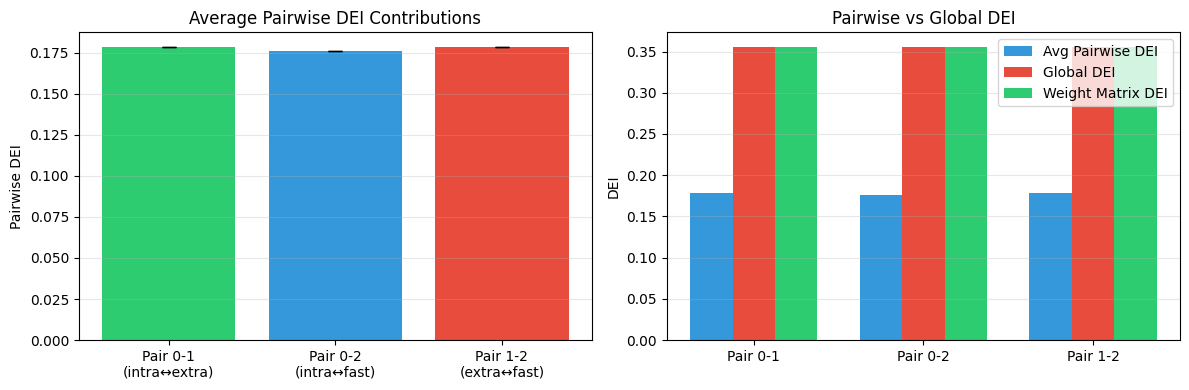

In [15]:
# Plot pairwise DEI comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of average pairwise DEI
ax1 = axes[0]
labels = ['Pair 0-1\n(intra↔extra)', 'Pair 0-2\n(intra↔fast)', 'Pair 1-2\n(extra↔fast)']
means = [np.mean(pairwise_results['pairwise_dei_01']),
         np.mean(pairwise_results['pairwise_dei_02']),
         np.mean(pairwise_results['pairwise_dei_12'])]
stds = [np.std(pairwise_results['pairwise_dei_01']),
        np.std(pairwise_results['pairwise_dei_02']),
        np.std(pairwise_results['pairwise_dei_12'])]

bars = ax1.bar(labels, means, yerr=stds, capsize=5, color=['#2ecc71', '#3498db', '#e74c3c'])
ax1.set_ylabel('Pairwise DEI')
ax1.set_title('Average Pairwise DEI Contributions')
ax1.grid(True, alpha=0.3, axis='y')

# Compare with global DEI
ax2 = axes[1]
x = np.arange(3)
width = 0.25
ax2.bar(x - width, means, width, label='Avg Pairwise DEI', color='#3498db')
ax2.bar(x, [np.mean(pairwise_results['global_dei'])]*3, width, label='Global DEI', color='#e74c3c')
ax2.bar(x + width, [np.mean(pairwise_results['weight_matrix_dei'])]*3, width, label='Weight Matrix DEI', color='#2ecc71')
ax2.set_xticks(x)
ax2.set_xticklabels(['Pair 0-1', 'Pair 0-2', 'Pair 1-2'])
ax2.set_ylabel('DEI')
ax2.set_title('Pairwise vs Global DEI')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pairwise_dei_analysis.png', dpi=150, bbox_inches='tight')
plt.show()